# EDA

### Import Libraries

In [1]:
from pathlib import Path
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import numpy as np
import seaborn as sns
import math
import itertools
import random
from sklearn.decomposition import PCA



import warnings
warnings.filterwarnings("ignore")

### Load Data from Notebook 1

The data loading and feature aggregation were completed in the previous notebook (01_data_loading.ipynb). The resulting merged datasets were saved as train_final.csv and test_final.csv. In this notebook, these datasets are loaded to perform exploratory data analysis (EDA) before preprocessing and model development.

Define OUTPUT_DIR using Path

In [2]:


PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "output"

print("Output directory:", OUTPUT_DIR)
print("Exists:", OUTPUT_DIR.exists())

Output directory: c:\Users\User\Desktop\final project\output
Exists: True


Load the files

In [3]:
train = pd.read_csv(OUTPUT_DIR / "train_final.csv")
test = pd.read_csv(OUTPUT_DIR / "test_final.csv")

print(train.shape)
print(test.shape)

(307511, 617)
(48744, 616)


The processed training and testing datasets were inspected to verify their dimensions and memory usage. The training dataset contained 307,511 observations and 617 variables, while the testing dataset contained 48,744 observations and 616 variables, with the difference attributable to the absence of the target variable in the test set.

### Data Preprocessing and EDA


### 1. Overview: shape, memory, target balance

In [4]:

print("Memory (train):", round(train.memory_usage(deep=True).sum()/1e9, 2), "GB")
print()
print("Target distribution:")
print(train['TARGET'].value_counts(normalize=True).round(4))

Memory (train): 1.56 GB

Target distribution:
TARGET
0    0.9193
1    0.0807
Name: proportion, dtype: float64


 The processed training data occupied approximately 1.56 GB of memory. Finally, the distribution of the target variable was examined and revealed that 91.93% of applicants repaid their loans, while 8.07% defaulted, indicating a substantial class imbalance that informed the choice of evaluation metrics during model development.

### 2. Missing values & duplicate rows

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 617 entries, SK_ID_CURR to INSTAL_LATE_RATE_TREND
dtypes: float64(560), int64(41), str(16)
memory usage: 1.5 GB


In [6]:
# checking for duplicates
train.duplicated().sum()

np.int64(0)

There are no duplicates

#### Identifying the missingness:


In [7]:

# Function to Generate a Missing Value Report


def missing_value_report(df, name="train"):

    # Count the number of missing (NaN) values in each column.
    missing_count = df.isna().sum()

    # Calculate the percentage of missing values in each column.
    missing_pct = (df.isna().mean() * 100).round(2)

    # Create a summary table containing the column name, number of missing values, and percentage of missing values.
    report = pd.DataFrame({
        "column": missing_count.index,
        "missing_count": missing_count.values,
        "missing_pct": missing_pct.values
    })

    # Keep only columns that have missing values, then sort them from the highest to the lowest percentage of missing data.
    report = (
        report[report["missing_count"] > 0]
        .sort_values("missing_pct", ascending=False)
        .reset_index(drop=True)
    )

    # Print Summary Statistics
    print(f"--- {name} ---")

    # Total number of columns
    print(f"Total columns: {df.shape[1]}")
    # Number of columns with missing values
    print(f"Columns with missing values: {len(report)}")
    # Number of columns with no missing values
    print(f"Columns with 0 missing: {df.shape[1] - len(report)}")
    print()
    # Number of columns with more than 90% missing values
    print(f"Columns >90% missing: {(report['missing_pct'] > 90).sum()}")
    # Number of columns with between 50% and 90% missing values
    print(f"Columns 50-90% missing: {((report['missing_pct'] > 50) & (report['missing_pct'] <= 90)).sum()}")
    # Number of columns with less than or equal to 50% missing values
    print(f"Columns <50% missing: {(report['missing_pct'] <= 50).sum()}")
    # Return the complete missing value report
    return report

# Generate Missing Value Reports

# Create a report for the training dataset.
train_missing = missing_value_report(train, "train")
# Create a report for the testing dataset.
test_missing = missing_value_report(test, "test")

# Display the Full Training Report


# Show the complete table of missing values,
# sorted from the highest percentage missing
# to the lowest.

train_missing

--- train ---
Total columns: 617
Columns with missing values: 562
Columns with 0 missing: 55

Columns >90% missing: 6
Columns 50-90% missing: 151
Columns <50% missing: 405
--- test ---
Total columns: 616
Columns with missing values: 559
Columns with 0 missing: 57

Columns >90% missing: 6
Columns 50-90% missing: 103
Columns <50% missing: 450


,column,missing_count,missing_pct
0,PREV_RATE_INTEREST_PRIVILEGED_MIN,302902,98.50
1,PREV_RATE_INTEREST_PRIMARY_MIN,302902,98.50
2,PREV_RATE_INTEREST_PRIVILEGED_MEAN,302902,98.50
3,PREV_RATE_INTEREST_PRIVILEGED_MAX,302902,98.50
4,PREV_RATE_INTEREST_PRIMARY_MEAN,302902,98.50
...,...,...,...
557,EXT_SOURCE_2,660,0.21
558,AMT_GOODS_PRICE,278,0.09
559,CNT_FAM_MEMBERS,2,0.00
560,DAYS_LAST_PHONE_CHANGE,1,0.00


#### ***Key insights***

1. The training dataset contains 617 features, of which 562 have at least one missing value, while only 55 features are complete. This shows that missing-value treatment will be an important part of the preprocessing stage before model development.
2. Missing values are not evenly distributed across the features. In the training data, 6 features have more than 90% missing values, 151 features have between 50% and 90% missing values, while 405 features have less than 50% missing values. This means that most features have some missing data, but the majority have less than 50% missingness.
3. The testing dataset shows a similar overall pattern, with 559 out of 616 features containing missing values and 57 features having no missing values. However, the distribution is somewhat different: 6 features have more than 90% missing values, 103 features have between 50% and 90%, and 450 features have less than 50% missing values. This suggests that missing-value handling will be required for both datasets.
4. The features with the highest levels of missingness are mainly aggregated variables related to previous loan interest rates. For example, PREV_RATE_INTEREST_PRIMARY_MIN and PREV_RATE_INTEREST_PRIVILEGED_MEAN are missing for approximately 98.5% of applicants. This is likely because interest-rate information was not recorded for most applicants who did not have the relevant type of previous loan or application.
5. On the other hand, several important features have very little missing data. For example, EXT_SOURCE_2 has only 0.21% missing values, while AMT_GOODS_PRICE, CNT_FAM_MEMBERS, DAYS_LAST_PHONE_CHANGE, and AMT_ANNUITY have less than 0.1% missing values. These features are therefore largely complete and should not require extensive missing-value treatment.

Overall, the missing-value analysis shows that different features will need different treatment. Features with extremely high missingness may need to be removed or handled carefully, while features with only a small number of missing values can be imputed using an appropriate strategy. Importantly, any imputation values should be learned from the training data and then applied to the validation and test data to avoid data leakage.

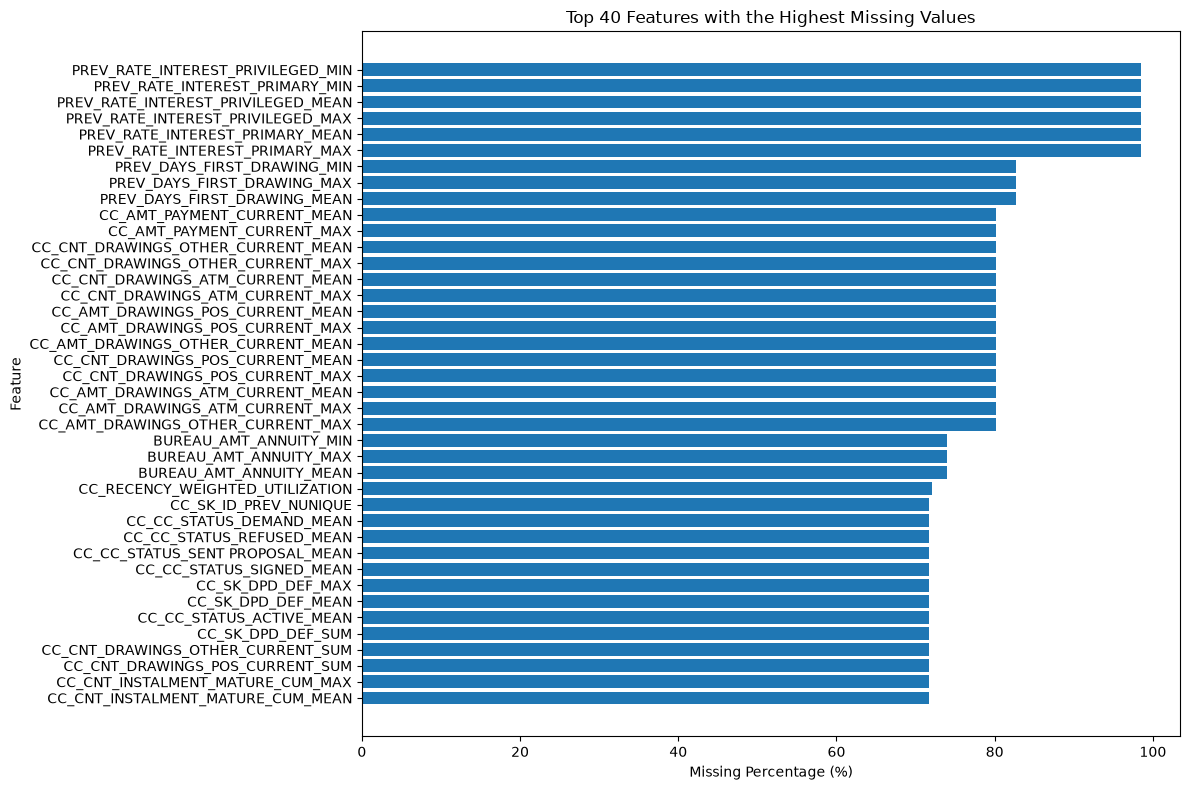

In [8]:
# Select the top 40 features with the highest missing percentages
top_missing = train_missing.head(40)

plt.figure(figsize=(12, 8))
plt.barh(top_missing["column"], top_missing["missing_pct"])

plt.xlabel("Missing Percentage (%)")
plt.ylabel("Feature")
plt.title("Top 40 Features with the Highest Missing Values")

# Display the highest percentage at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

The concentration of missing values within the PREV_ (previous applications), CC_ (credit card history), and BUREAU_ (credit history from other financial institutions) feature groups suggests that the missingness is largely related to whether an applicant has a particular type of financial history recorded, rather than missing values occurring randomly. This pattern will be considered when selecting appropriate missing-value treatment techniques during preprocessing.

Before building the machine learning models, I first assessed the quality of the dataset by checking for missing values. This function calculates the number and percentage of missing values for each feature and summarizes the extent of missingness across the dataset. The results help identify features that require further attention and guide the selection of appropriate missing value handling methods during the preprocessing stage.

## Handling the missingness

#### Step 1: Separate numeric and categorical features

In [9]:

# Numeric features (exclude target and ID)
numeric_cols = (
    train.select_dtypes(include=np.number)
         .columns
         .drop(["TARGET", "SK_ID_CURR"], errors="ignore")
         .tolist()
)

# Categorical features
categorical_cols = (
    train.select_dtypes(include=["object", "string"])
         .columns
         .tolist()
)

print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Numeric features: 599
Categorical features: 16


#### Step 2: Inspecting the feature groups

see exactly what kinds of variables are in each group.

In [10]:
# Credit card features
cc_cols = sorted([c for c in train.columns if c.startswith("CC_")])

# Bureau features
bureau_cols = sorted([c for c in train.columns if c.startswith("BUREAU_")])

# Previous application features
prev_cols = sorted([c for c in train.columns if c.startswith("PREV_")])

# POS Cash features
pos_cols = sorted([c for c in train.columns if c.startswith("POS_")])

# Installment features
instal_cols = sorted([c for c in train.columns if c.startswith("INSTAL_")])

print(f"CC features: {len(cc_cols)}")
print(f"BUREAU features: {len(bureau_cols)}")
print(f"PREV features: {len(prev_cols)}")
print(f"POS features: {len(pos_cols)}")
print(f"INSTAL features: {len(instal_cols)}")

CC features: 71
BUREAU features: 133
PREV features: 216
POS features: 25
INSTAL features: 50


495 of the 615 features come from historical customer behaviour, including 216 PREV_ features, 133 BUREAU_ features, 71 CC_ features, 25 POS_ features, and 50 INSTAL_ features. This shows that most of the dataset is based on applicants' past financial history. Therefore, missing values in these features may indicate that a particular type of history is unavailable rather than simply being random missing data. A single blanket imputation strategy may therefore not be appropriate for all features; missing values should be handled based on the meaning and source of each feature.

#### Step 3: Display sample feature names

This helps in verifying the naming pattern.

In [11]:
print("CC")
print(cc_cols[:20])

print("\nBUREAU")
print(bureau_cols[:20])

print("\nPREV")
print(prev_cols[:20])

print("\nPOS")
print(pos_cols[:20])

print("\nINSTAL")
print(instal_cols[:20])

CC
['CC_AMT_BALANCE_MAX', 'CC_AMT_BALANCE_MEAN', 'CC_AMT_BALANCE_SUM', 'CC_AMT_CREDIT_LIMIT_ACTUAL_MAX', 'CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN', 'CC_AMT_CREDIT_LIMIT_ACTUAL_SUM', 'CC_AMT_DRAWINGS_ATM_CURRENT_MAX', 'CC_AMT_DRAWINGS_ATM_CURRENT_MEAN', 'CC_AMT_DRAWINGS_ATM_CURRENT_SUM', 'CC_AMT_DRAWINGS_CURRENT_MAX', 'CC_AMT_DRAWINGS_CURRENT_MEAN', 'CC_AMT_DRAWINGS_CURRENT_SUM', 'CC_AMT_DRAWINGS_OTHER_CURRENT_MAX', 'CC_AMT_DRAWINGS_OTHER_CURRENT_MEAN', 'CC_AMT_DRAWINGS_OTHER_CURRENT_SUM', 'CC_AMT_DRAWINGS_POS_CURRENT_MAX', 'CC_AMT_DRAWINGS_POS_CURRENT_MEAN', 'CC_AMT_DRAWINGS_POS_CURRENT_SUM', 'CC_AMT_INST_MIN_REGULARITY_MAX', 'CC_AMT_INST_MIN_REGULARITY_MEAN']

BUREAU
['BUREAU_AMT_ANNUITY_MAX', 'BUREAU_AMT_ANNUITY_MEAN', 'BUREAU_AMT_ANNUITY_MIN', 'BUREAU_AMT_ANNUITY_SUM', 'BUREAU_AMT_CREDIT_MAX_OVERDUE_MAX', 'BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN', 'BUREAU_AMT_CREDIT_MAX_OVERDUE_MIN', 'BUREAU_AMT_CREDIT_MAX_OVERDUE_SUM', 'BUREAU_AMT_CREDIT_SUM_DEBT_MAX', 'BUREAU_AMT_CREDIT_SUM_DEBT_MEAN', 'BUREAU

### Step 4: create the groups
**Group 1: Zero-fill features**

**Group 2: Median Features**

I don't want to fill every missing numerical value with the same thing. If a feature represents a count, total, or number of unique records, zero may make sense when there is no history. For other numerical features, especially day-related and continuous measurements, I'll use the median. Finally, I'll check that every numerical feature has been assigned to exactly one of these two groups.

This code is deciding how each numerical feature should be treated when it has a missing value. Instead of using the same imputation method for every numerical column, it creates two groups: features where a missing value can reasonably mean zero, and features where the missing value should be replaced with the median.

In [12]:

# Define Imputation Groups


# Features where 0 is meaningful
zero_fill_cols = [
    c for c in numeric_cols
    if (
        c.endswith("_SUM")
        or c.endswith("_COUNT")
        or c.endswith("_NUNIQUE")
    )
]

# Move day-related aggregates to median
day_sum_cols = [
    c for c in zero_fill_cols
    if "DAYS" in c
]

zero_fill_cols = [
    c for c in zero_fill_cols
    if c not in day_sum_cols
]

# Manually include important count features
manual_zero_fill = [
    "INSTAL_SK_ID_PREV_NUNIQUE",
    "POS_SK_ID_PREV_NUNIQUE"
]

manual_zero_fill = [
    c for c in manual_zero_fill
    if c in train.columns
]

zero_fill_cols = sorted(
    list(set(zero_fill_cols + manual_zero_fill))
)

# All remaining numeric features use median
median_fill_cols = [
    c for c in numeric_cols
    if c not in zero_fill_cols
]


# Verification

print(f"Zero-fill features : {len(zero_fill_cols)}")
print(f"Median-fill features: {len(median_fill_cols)}")

assert len(set(zero_fill_cols).intersection(set(median_fill_cols))) == 0
assert len(zero_fill_cols) + len(median_fill_cols) == len(numeric_cols)

print("✓ Every numeric feature assigned correctly.")

Zero-fill features : 63
Median-fill features: 536
✓ Every numeric feature assigned correctly.


In [13]:
print("Zero-fill examples:")
print(sorted(zero_fill_cols[:30]))

print("\nMedian examples:")
print(sorted(median_fill_cols[:30]))

Zero-fill examples:
['BUREAU_AMT_ANNUITY_SUM', 'BUREAU_AMT_CREDIT_MAX_OVERDUE_SUM', 'BUREAU_AMT_CREDIT_SUM_DEBT_SUM', 'BUREAU_AMT_CREDIT_SUM_LIMIT_SUM', 'BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM', 'BUREAU_AMT_CREDIT_SUM_SUM', 'BUREAU_BB_MONTHS_COUNT_SUM', 'BUREAU_BB_MONTHS_MAX_SUM', 'BUREAU_BB_MONTHS_MIN_SUM', 'BUREAU_BB_STATUS_0_SUM', 'BUREAU_BB_STATUS_1_SUM', 'BUREAU_BB_STATUS_2_SUM', 'BUREAU_BB_STATUS_3_SUM', 'BUREAU_BB_STATUS_4_SUM', 'BUREAU_BB_STATUS_5_SUM', 'BUREAU_BB_STATUS_C_SUM', 'BUREAU_BB_STATUS_X_SUM', 'BUREAU_CNT_CREDIT_PROLONG_SUM', 'BUREAU_CREDIT_DAY_OVERDUE_SUM', 'BUREAU_L2Y_COUNT', 'BUREAU_SK_ID_BUREAU_COUNT', 'CC_AMT_BALANCE_SUM', 'CC_AMT_CREDIT_LIMIT_ACTUAL_SUM', 'CC_AMT_DRAWINGS_ATM_CURRENT_SUM', 'CC_AMT_DRAWINGS_CURRENT_SUM', 'CC_AMT_DRAWINGS_OTHER_CURRENT_SUM', 'CC_AMT_DRAWINGS_POS_CURRENT_SUM', 'CC_AMT_INST_MIN_REGULARITY_SUM', 'CC_AMT_PAYMENT_CURRENT_SUM', 'CC_AMT_PAYMENT_TOTAL_CURRENT_SUM']

Median examples:
['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_INCOME

### Step 5:Create missing indicators.

For every numerical feature with more than 70% missing values, a missing-value indicator will be created.

Why 70%?
Because when a feature is missing for such a large proportion of applicants, the missingness may itself provide useful information. For example, a missing value may indicate that an applicant does not have a particular type of financial history or record. The indicator allows the model to distinguish between a value that was genuinely recorded and one that was missing, rather than losing this information during imputation.

In [14]:
missing_pct = train[numeric_cols].isna().mean()

indicator_cols = missing_pct[
    missing_pct > 0.70
].index.tolist()

print(len(indicator_cols))

116


#### Step 6: Create the indicators

In [15]:
for col in indicator_cols:
    train[f"{col}_WAS_MISSING"] = train[col].isna().astype("int8")
    test[f"{col}_WAS_MISSING"] = test[col].isna().astype("int8")

In [16]:
print(train.shape)
print(test.shape)

(307511, 733)
(48744, 732)


#### Step 7: Fill the structural features

In [17]:
train[zero_fill_cols] = train[zero_fill_cols].fillna(0)
test[zero_fill_cols] = test[zero_fill_cols].fillna(0)

#### Step 8: Median

In [18]:
median_imputer = SimpleImputer(strategy="median")

train[median_fill_cols] = median_imputer.fit_transform(train[median_fill_cols])

test[median_fill_cols] = median_imputer.transform(test[median_fill_cols])

#### Step 9: Categorical

In [19]:
train[categorical_cols] = train[categorical_cols].fillna("Missing")
test[categorical_cols] = test[categorical_cols].fillna("Missing")


#### Step 10: Verify Missing Values


In [20]:
print("Remaining missing values")
print("------------------------")

print(f"Train: {train.isna().sum().sum():,}")
print(f"Test : {test.isna().sum().sum():,}")

assert train.isna().sum().sum() == 0
assert test.isna().sum().sum() == 0

print("\n✓ Missing value treatment completed successfully.")

Remaining missing values
------------------------
Train: 0
Test : 0

✓ Missing value treatment completed successfully.


#### ***Missing Value Treatment***

Missing values were handled differently depending on what each feature represents, rather than using one method for everything.

- Count, total, and unique-count features such as *_COUNT, *_NUNIQUE, and most *_SUM features were filled with 0. For historical features, a missing value often means the applicant had no recorded activity in that area.
- Day-based aggregate features were treated separately and filled using the median, because a missing day value does not necessarily mean zero activity.
- Other numerical features, including financial amounts, averages, minimums, maximums, ratios, and applicant characteristics, were filled with the median. This is safer than using 0 because 0 could represent a real value and these variables can be highly skewed.
- For numerical features with more than 70% missing values, a separate _WAS_MISSING indicator was created. This records whether the original value was missing (1) or available (0). The idea is that, especially for historical features, having no recorded history itself may carry useful information.
- Categorical features were filled with a new category called "Missing". This allows the model to distinguish between an actual category and the fact that the information was unavailable.

## checking for data anomalies 

A data anomaly is any value in the dataset that looks abnormal or does not follow the expected pattern.

In [21]:
def scan_for_placeholder_anomalies(df, min_pct=0.5, iqr_multiplier=3):
    """
    Detect repeated extreme values that are likely placeholder codes
    rather than genuine observations.
    """

    findings = []

    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:

        # Skip binary variables
        if df[col].nunique() <= 2:
            continue

        value_counts = df[col].value_counts()

        top_value = value_counts.index[0]
        top_count = value_counts.iloc[0]
        top_pct = top_count / len(df) * 100

        if top_pct < min_pct:
            continue

        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1

        if iqr == 0:
            continue

        lower = q1 - iqr_multiplier * iqr
        upper = q3 + iqr_multiplier * iqr

        if top_value < lower or top_value > upper:

            findings.append({
                "column": col,
                "suspicious_value": top_value,
                "count": top_count,
                "pct_of_rows": round(top_pct, 2),
                "normal_range": f"[{lower:.1f}, {upper:.1f}]"
            })

    return (
        pd.DataFrame(findings)
        .sort_values("pct_of_rows", ascending=False)
        .reset_index(drop=True)
    )

In [22]:
anomaly_report = scan_for_placeholder_anomalies(train)

print(f"Found {len(anomaly_report)} suspicious placeholder values.")

anomaly_report

Found 1 suspicious placeholder values.


,column,suspicious_value,count,pct_of_rows,normal_range
0,DAYS_EMPLOYED,365243.0,55374,18.01,"[-10173.0, 7124.0]"


DAYS_EMPLOYED anomaly count: 55374
As % of rows: 18.01


<Axes: title={'center': 'DAYS_EMPLOYED before fix'}, ylabel='Frequency'>

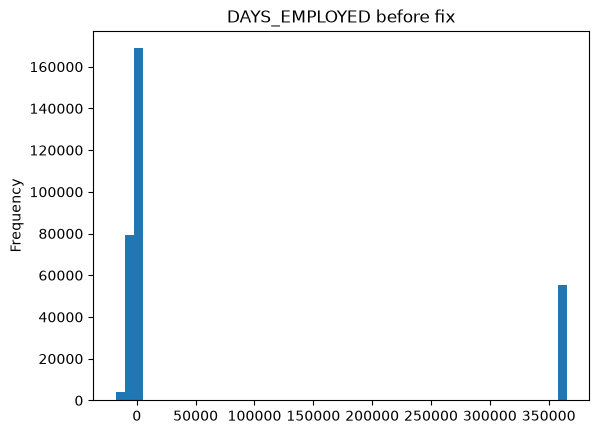

In [23]:
print("DAYS_EMPLOYED anomaly count:", (train['DAYS_EMPLOYED'] == 365243).sum())
print("As % of rows:", round((train['DAYS_EMPLOYED'] == 365243).mean()*100, 2))

# Before fixing, distribution is bimodal/broken:
train['DAYS_EMPLOYED'].plot(kind='hist', bins=50, title='DAYS_EMPLOYED before fix')

DAYS_EMPLOYED is supposed to tell you how many days ago someone started their current job. But Home Credit uses a strange trick: for people who aren't currently employed, instead of leaving this blank, they put in the number 365243 - which works out to roughly 1,000 years. That's obviously not a real answer, it's just a placeholder meaning "not applicable."

This code checks how big of a problem that placeholder actually is in your data:

- It counts exactly how many rows have that fake 365243 value.
- It turns that count into a percentage, so you know how much of your dataset is affected (a few rows would barely matter, but if it's a big chunk, it needs fixing).
- It draws a histogram (a bar chart showing how values are spread out) of DAYS_EMPLOYED as-is. 

Since real values are all fairly small numbers (days someone has worked, so ranging maybe from 0 up to a few thousand) and the fake value is enormous by comparison (365,243), the chart ends up looking broken - as shown  a normal-looking cluster of real values, plus a weird separate spike way off to the side for everyone with the placeholder.

-  That visual is the "before" picture, so later (when the column is fixed  by replacing 365243 with a proper blank value) you can compare it to an "after" picture and see the difference clearly.

#### Fixing the anomaly

In [24]:
days_employed_median = train.loc[
    train["DAYS_EMPLOYED"] != 365243,
    "DAYS_EMPLOYED"
].median()

train["DAYS_EMPLOYED_ANOM"] = (
    train["DAYS_EMPLOYED"] == 365243
).astype("int8")

test["DAYS_EMPLOYED_ANOM"] = (
    test["DAYS_EMPLOYED"] == 365243
).astype("int8")

train["DAYS_EMPLOYED"] = (
    train["DAYS_EMPLOYED"]
    .replace(365243, np.nan)
    .fillna(days_employed_median)
)

test["DAYS_EMPLOYED"] = (
    test["DAYS_EMPLOYED"]
    .replace(365243, np.nan)
    .fillna(days_employed_median)
)

In [25]:
print((train["DAYS_EMPLOYED"] == 365243).sum())
print((test["DAYS_EMPLOYED"] == 365243).sum())


0
0


Before building the machine learning models, I checked the dataset for anomalies to identify values that were unusual or incorrect. The anomaly detection process found that the DAYS_EMPLOYED feature contained the repeated value 365243, which is a known placeholder used in the Home Credit dataset to represent missing employment information rather than the actual number of days a customer has been employed.

To preserve this information, I first created a new binary feature called DAYS_EMPLOYED_ANOM, which records whether the original value was the placeholder or not. I then replaced the placeholder value (365243) with NaN so that it would not be treated as a real employment duration during analysis. Finally, I also replaced any positive or negative infinite (±∞) values with NaN to ensure the dataset contained only valid numeric values before the missing value imputation step.

This approach prevents invalid values from affecting the analysis while preserving potentially useful information about the original anomaly for the machine learning models.

## Outliers Analysis

1. Outlier summary report

In [26]:

# Detect Outliers Using the IQR Method


def outlier_summary(df):

    results = []

    numeric_cols = df.select_dtypes(include=np.number).columns

    # Exclude target, ID, and anomaly indicator
    exclude = ["TARGET", "SK_ID_CURR", "DAYS_EMPLOYED_ANOM"]

    numeric_cols = [
        col for col in numeric_cols
        if col not in exclude
    ]

    for col in numeric_cols:

        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)

        iqr = q3 - q1

        if iqr == 0:
            continue

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outliers = (
            (df[col] < lower) |
            (df[col] > upper)
        ).sum()

        results.append({
            "Feature": col,
            "Outlier Count": outliers,
            "Outlier Percentage": round(outliers / len(df) * 100, 2)
        })

    return (
        pd.DataFrame(results)
        .sort_values("Outlier Percentage", ascending=False)
        .reset_index(drop=True)
    )

outlier_report = outlier_summary(train)

outlier_report.head(20)

,Feature,Outlier Count,Outlier Percentage
0,YEARS_BEGINEXPLUATATION_MEDI,142141,46.22
1,YEARS_BEGINEXPLUATATION_AVG,142016,46.18
2,TOTALAREA_MODE,141917,46.15
3,YEARS_BEGINEXPLUATATION_MODE,141861,46.13
4,INSTAL_NUM_INSTALMENT_VERSION_MEAN,90221,29.34
5,INSTAL_AMT_PAYMENT_DIFF_SUM,77933,25.34
6,INSTAL_AMT_PAYMENT_DIFF_MEAN,75574,24.58
7,INSTAL_AMT_PAYMENT_RATIO_MEAN,67293,21.88
8,CC_AMT_CREDIT_LIMIT_ACTUAL_SUM,62304,20.26
9,BUREAU_DAYS_CREDIT_ENDDATE_SUM,60321,19.62


In [27]:
# Summary statistics
print(f"Features analysed: {len(outlier_report)}")

print(
    f"Features with at least one outlier: "
    f"{(outlier_report['Outlier Count'] > 0).sum()}"
)

Features analysed: 308
Features with at least one outlier: 179


2. Boxplot

In a boxplot :

1. The line inside the box represents the median (the middle value).
2. The box represents the middle 50% of the data (from the 25th to the 75th percentile).
3. The whiskers show the range of most normal observations.
4. The small circles (dots) outside the whiskers are outliers-values that are much higher or lower than most observations.

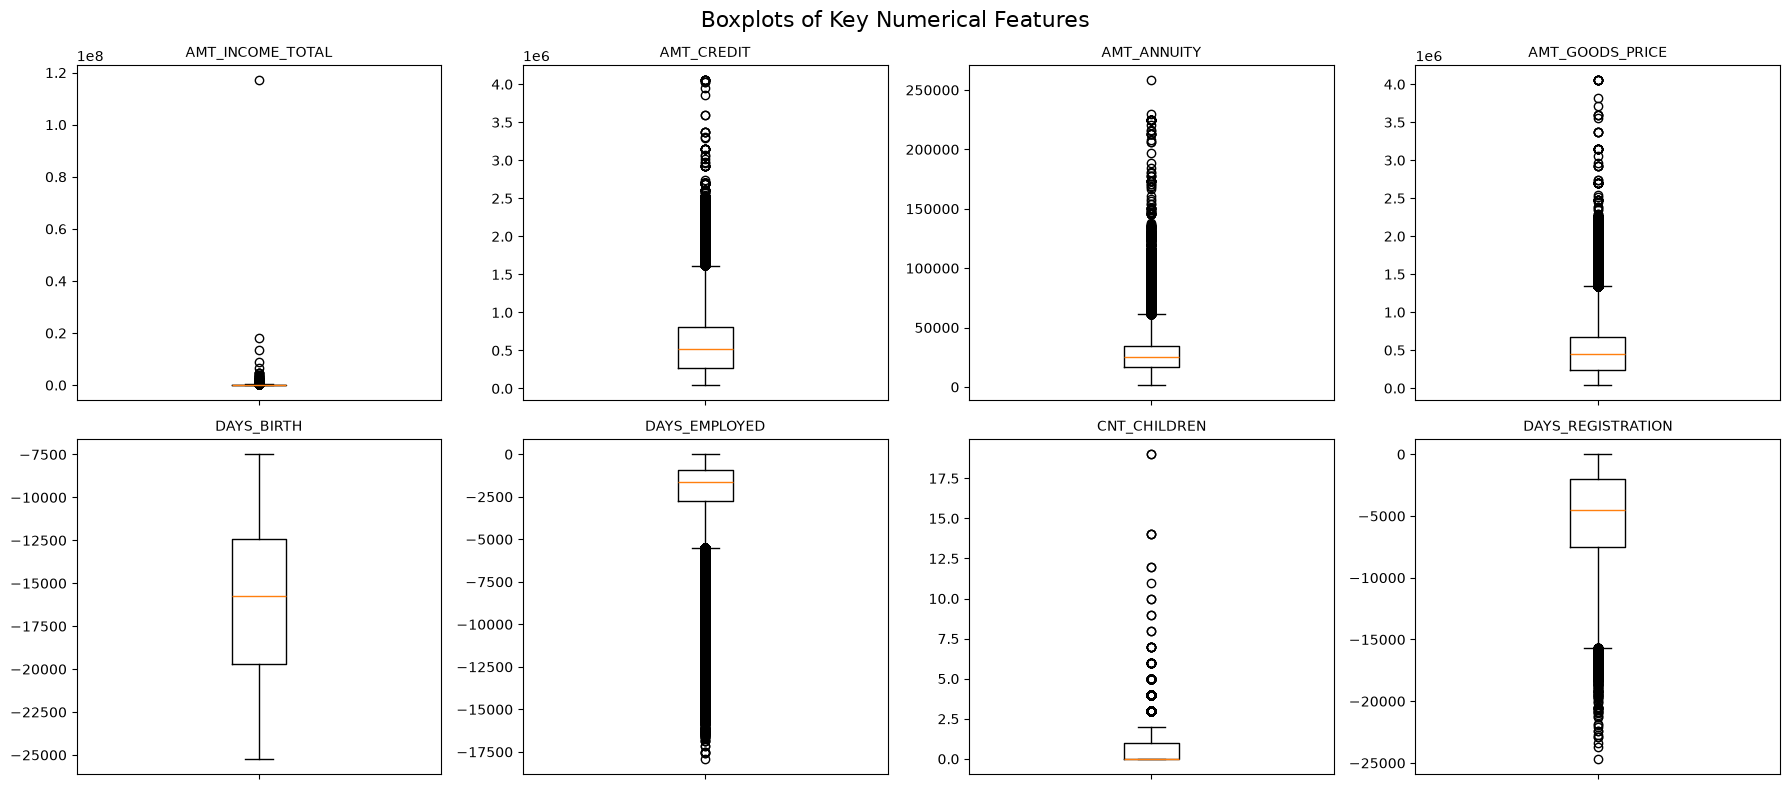

In [28]:

key_cols = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'CNT_CHILDREN',
    'DAYS_REGISTRATION'
]

# Keep only columns that exist
key_cols = [c for c in key_cols if c in train.columns]

# Create a 2 x 4 grid of plots
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Flatten the axes array for easy looping
axes = axes.flatten()

for ax, col in zip(axes, key_cols):
    ax.boxplot(train[col].dropna(), vert=True)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("")
    ax.tick_params(axis='x', labelbottom=False)

plt.suptitle("Boxplots of Key Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

The boxplots show that several financial variables, including AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY, and AMT_GOODS_PRICE, contain numerous outliers. This is expected because customers naturally differ in their income levels, loan amounts, repayment obligations, and purchasing power. The variables DAYS_EMPLOYED, CNT_CHILDREN, and DAYS_REGISTRATION also contain a small number of extreme observations that reflect genuine customer characteristics rather than data quality issues.

Since the identified outliers are likely to represent valid customer behaviour and the machine learning models used in this project (Random Forest, XGBoost, and LightGBM) are generally robust to outliers, these observations were retained for model development rather than removed or capped. This helps preserve valuable information that may improve the prediction of credit default risk.

## Correlation Analysis

A full correlation matrix - all numeric columns against each other with a 500+ numeric columns,  the grid will be 500x500 which is  unreadable as a heatmap and slow to compute. 

Therefore, below are two more practical versions for a dataset this wide:

1. Heatmap of just a manageable subset (e.g. the original raw features):

A correlation matrix shows the strength and direction of the linear relationship between the selected numerical features and the target variable. Correlation values range from -1 to +1, where:

* +1 = Perfect positive relationship (both variables increase together)
* -1 = Perfect negative relationship (one increases while the other decreases)
* 0 = No linear relationship

#### Step 1: Correlation with the Target

In [29]:
# Correlation of every numeric feature with TARGET 

target_corr = (
    train.drop(columns=["SK_ID_CURR"], errors="ignore")
         .corrwith(train["TARGET"], numeric_only=True)
         .drop("TARGET")
         .sort_values()
)

print("Top Positive Correlations")
display(target_corr.tail(10))

print("Top Negative Correlations")
display(target_corr.head(10))

Top Positive Correlations


INSTAL_L12M_LATE_RATE                               0.068837
INSTAL_LATE_RATE_OVERALL                            0.070190
PREV_L2Y_REFUSED_MEAN                               0.076363
PREV_NAME_CONTRACT_STATUS_REFUSED_MEAN              0.077894
DAYS_BIRTH                                          0.078239
CC_RECENCY_WEIGHTED_UTILIZATION                     0.078360
PREV_RECENCY_WEIGHTED_REFUSAL_RATE                  0.079178
BUREAU_DAYS_CREDIT_MEAN                             0.082079
INSTAL_RECENCY_WEIGHTED_LATE_RATE                   0.085351
PREV_NAME_GOODS_CATEGORY_HOUSE CONSTRUCTION_MEAN         NaN
dtype: float64

Top Negative Correlations


EXT_SOURCE_2                              -0.160295
EXT_SOURCE_3                              -0.155892
EXT_SOURCE_1                              -0.098887
PREV_CODE_REJECT_REASON_XAP_MEAN          -0.074348
BUREAU_CREDIT_ACTIVE_CLOSED_MEAN          -0.070352
PREV_NAME_CONTRACT_STATUS_APPROVED_MEAN   -0.062983
INSTAL_DAYS_INSTALMENT_STD                -0.056596
INSTAL_DAYS_ENTRY_PAYMENT_STD             -0.056149
BUREAU_LAST_LOAN_CREDIT_ACTIVE_Closed     -0.050733
BUREAU_LAST_LOAN_CREDIT_AGE_DAYS          -0.048847
dtype: float64

#### Step 2: Visualize the Most Important Features

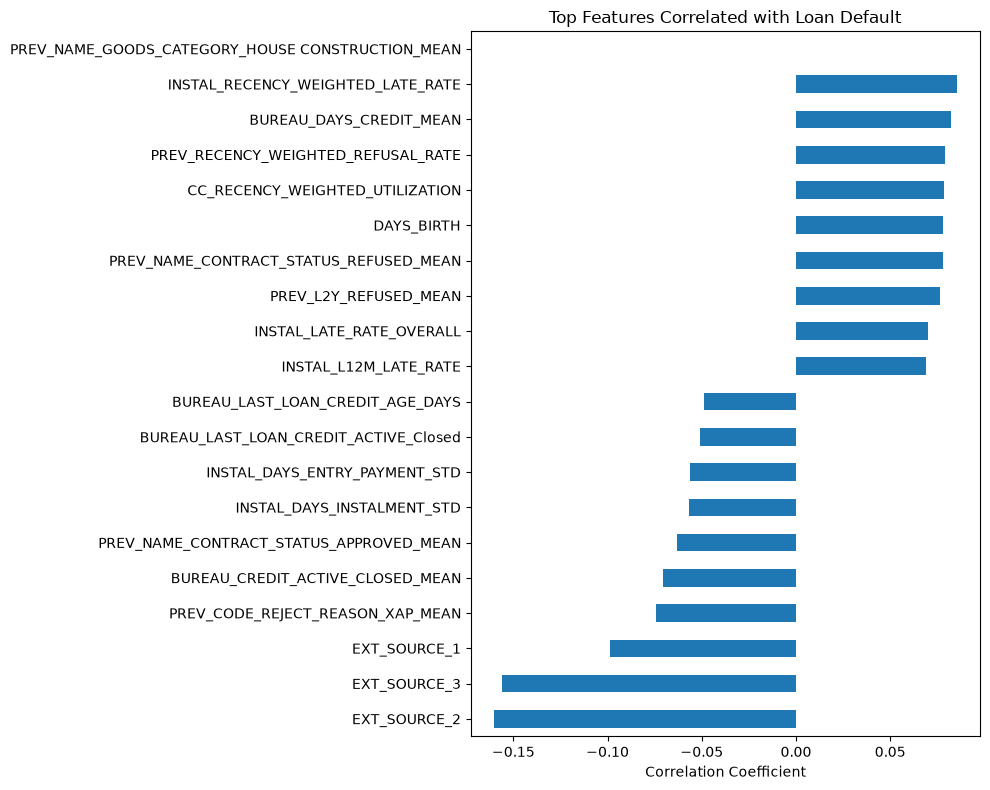

In [30]:

top_features = pd.concat([
    target_corr.head(10),
    target_corr.tail(10)
])

plt.figure(figsize=(10,8))
top_features.sort_values().plot(kind="barh")

plt.title("Top Features Correlated with Loan Default")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

## Insights from the Top Negative Correlations (Protective Factors)

| Feature | Correlation | Interpretation |
|---|---:|---|
| **EXT_SOURCE_2** | -0.160 | Higher external credit scores were associated with a lower likelihood of default. This was the strongest protective feature identified. |
| **EXT_SOURCE_3** | -0.156 | Higher external credit scores were associated with lower default risk. |
| **EXT_SOURCE_1** | -0.099 | Better external credit scores were linked to a lower likelihood of default. |
| **PREV_CODE_REJECT_REASON_XAP_MEAN** | -0.074 | This previous-application feature had a weak negative relationship with default, suggesting slightly lower default risk. |
| **BUREAU_CREDIT_ACTIVE_CLOSED_MEAN** | -0.070 | Applicants with a higher proportion of closed credit accounts tended to have a slightly lower likelihood of default. |
| **PREV_NAME_CONTRACT_STATUS_APPROVED_MEAN** | -0.063 | Applicants with a higher proportion of previously approved applications were slightly less likely to default. |
| **INSTAL_DAYS_INSTALMENT_STD** | -0.057 | Greater variation in scheduled installment dates showed a weak negative relationship with default. |
| **INSTAL_DAYS_ENTRY_PAYMENT_STD** | -0.056 | Greater variation in payment entry dates was weakly associated with lower default risk. |
| **INSTAL_AMT_PAYMENT_RATIO_MIN** | -0.047 | This installment payment feature showed a weak negative relationship with default. |
| **PREV_DAYS_FIRST_DRAWING_MIN_WAS_MISSING** | -0.045 | Missing values for this previous-application feature were weakly associated with a lower probability of default. |



## Insights from the Top Positive Correlations (Risk Factors)

| Feature | Correlation | Interpretation |
|---|---:|---|
| **INSTAL_RECENCY_WEIGHTED_LATE_RATE** | 0.085 | A higher recent rate of late installment payments was associated with a slightly higher likelihood of default. This was the strongest positive relationship identified. |
| **BUREAU_DAYS_CREDIT_MEAN** | 0.082 | This bureau credit-history feature showed a weak positive relationship with default. |
| **PREV_RECENCY_WEIGHTED_REFUSAL_RATE** | 0.079 | A higher recent rate of refused previous applications was weakly associated with higher default risk. |
| **PREV_NAME_CONTRACT_STATUS_REFUSED_MEAN** | 0.078 | Applicants with a higher proportion of previously refused applications showed a slightly higher default risk. |
| **DAYS_BIRTH** | 0.078 | Since `DAYS_BIRTH` is stored as a negative value, a positive correlation indicates that younger applicants were slightly more likely to default. |
| **CC_RECENCY_WEIGHTED_UTILIZATION** | 0.078 | Higher recent credit-card utilization was weakly associated with a higher likelihood of default. |
| **BUREAU_CREDIT_ACTIVE_ACTIVE_MEAN** | 0.069 | Having a higher proportion of active credit accounts was weakly associated with a higher probability of default. |
| **BUREAU_DAYS_CREDIT_MIN** | 0.067 | This bureau credit-history feature showed a weak positive relationship with default. |
| **BUREAU_DAYS_CREDIT_UPDATE_MEAN** | 0.064 | Higher values of this bureau feature were weakly associated with a higher likelihood of default. |
| **REGION_RATING_CLIENT_W_CITY** | 0.061 | Applicants in regions with higher risk ratings were slightly more likely to default. |
| **REGION_RATING_CLIENT** | 0.059 | Higher regional risk ratings showed a weak positive relationship with loan default. |



## Overall Insight

The correlation analysis shows that **no individual feature has a strong linear relationship with loan default**. The strongest relationship was `EXT_SOURCE_2`, with a correlation of only **-0.160**.

The strongest **protective factors** were the external credit score features (`EXT_SOURCE_1`, `EXT_SOURCE_2`, and `EXT_SOURCE_3`). Higher external scores were generally associated with a lower likelihood of default.

The strongest **risk factors** were mainly related to **recent repayment behaviour and previous credit history**, particularly recent late-payment rates, previous loan refusals, and credit-card utilization.

Overall, the results suggest that **loan default is not driven by one single factor**. Instead, it is influenced by a combination of applicant characteristics, previous credit history, credit-card behaviour, and repayment behaviour.

This supports the use of machine learning models such as **Random Forest, XGBoost, and LightGBM**, which can capture more complex and non-linear relationships between multiple features and the probability of default.

## Feature distribution

#### Step 1: Select Key Numerical Features

In [31]:

key_numeric = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "REGION_POPULATION_RELATIVE",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

# Keep only columns that exist
key_numeric = [c for c in key_numeric if c in train.columns]

print(key_numeric)

['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'REGION_POPULATION_RELATIVE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']


#### Step 2: Plot Feature Distributions

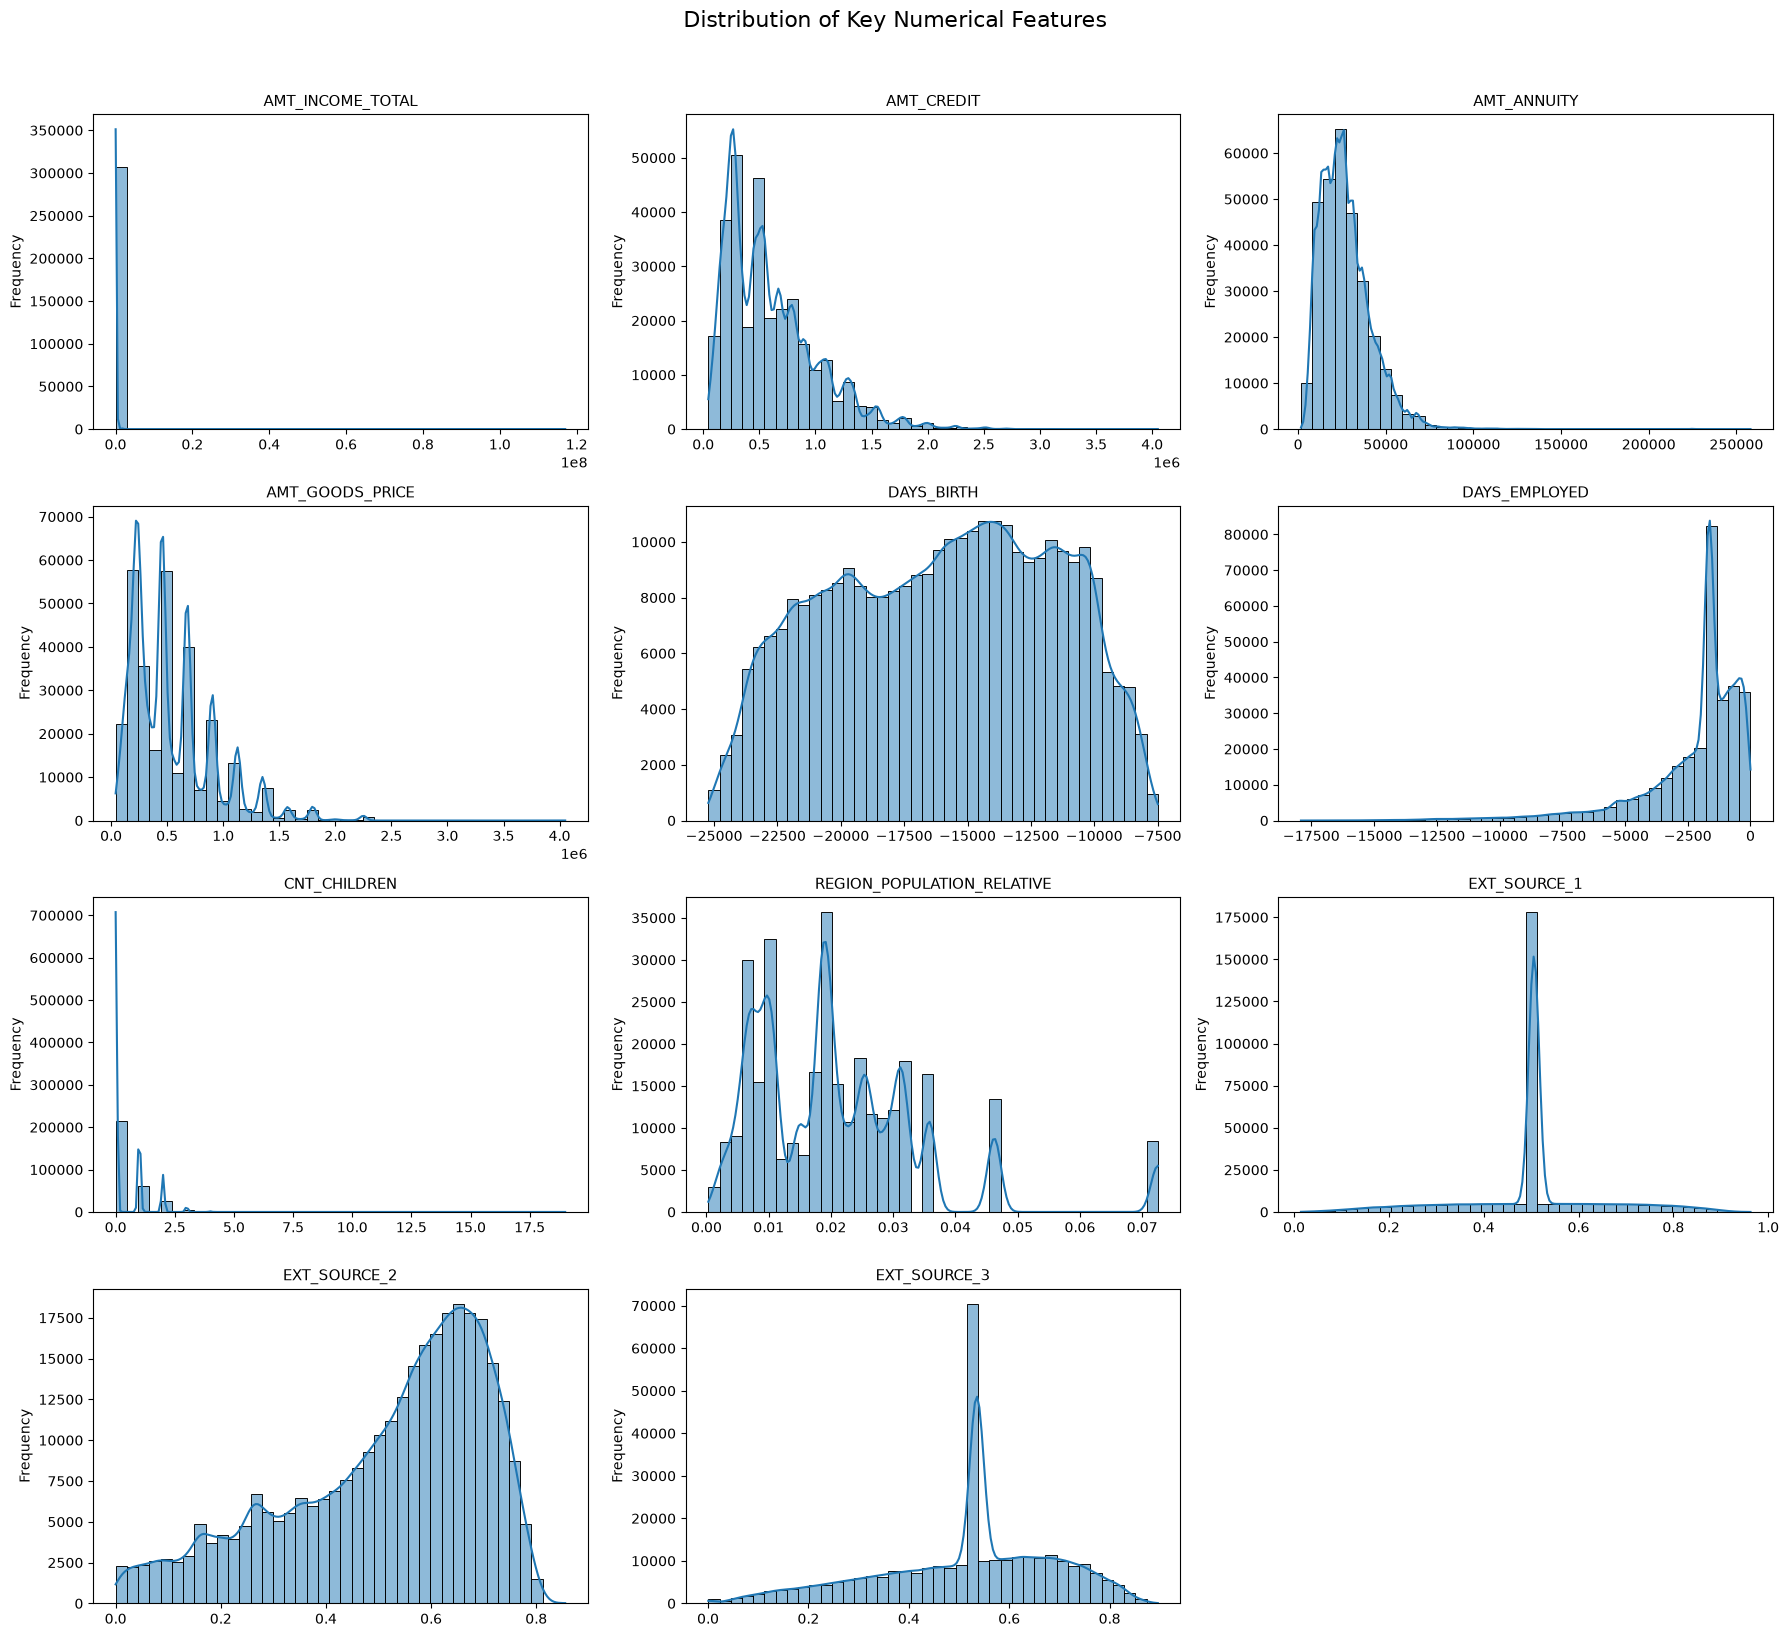

In [32]:

# Number of columns in the layout
n_cols = 3
n_rows = math.ceil(len(key_numeric) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))

# Flatten axes for easy iteration
axes = axes.flatten()

for ax, col in zip(axes, key_numeric):
    sns.histplot(
        train[col].dropna(),
        bins=40,
        kde=True,
        ax=ax
    )

    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

# Remove any empty subplots
for ax in axes[len(key_numeric):]:
    fig.delaxes(ax)

plt.suptitle("Distribution of Key Numerical Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

#### Step 3: Compute Skewness

In [33]:
skewness = (
    train[key_numeric]
    .skew()
    .sort_values(key=abs, ascending=False)
    .to_frame("Skewness")
)

skewness

,Skewness
AMT_INCOME_TOTAL,391.559654
DAYS_EMPLOYED,-2.295849
CNT_CHILDREN,1.974604
AMT_ANNUITY,1.579824
REGION_POPULATION_RELATIVE,1.488009
AMT_GOODS_PRICE,1.350143
AMT_CREDIT,1.234778
EXT_SOURCE_2,-0.795940
EXT_SOURCE_3,-0.537697
EXT_SOURCE_1,-0.150998


#### Step 4: Visualize the Skewness

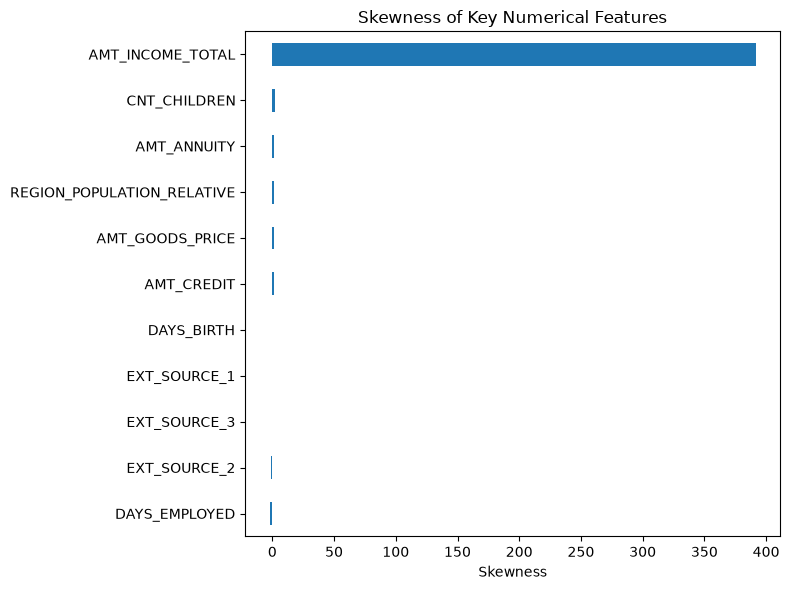

In [34]:
plt.figure(figsize=(8,6))

skewness["Skewness"].sort_values().plot(kind="barh")

plt.title("Skewness of Key Numerical Features")
plt.xlabel("Skewness")

plt.tight_layout()
plt.show()

#### **Feature Distribution Analysis**

The histograms show that most financial variables are positively skewed, with many applicants having relatively low values and only a few having extremely large values. This pattern is confirmed by the skewness statistics.

1. ***AMT_INCOME_TOTAL*** is extremely positively skewed (skewness = 391.56), indicating that while most applicants earn moderate incomes, a few have exceptionally high incomes.

2. ***AMT_CREDIT, AMT_ANNUITY, and AMT_GOODS_PRICE*** are moderately positively skewed (skewness between 1.23 and 1.58), showing that most applicants receive moderate loan amounts while relatively few receive very large loans.

3. ***CNT_CHILDREN*** is positively skewed (skewness = 1.97) because most applicants have no children or only a few children.

4. ***DAYS_EMPLOYED*** remains positively skewed (skewness = 1.66) due to the placeholder value identified earlier as an anomaly.

5. ***DAYS_BIRTH*** is approximately symmetric (skewness = −0.12), suggesting that applicant ages are fairly evenly distributed.

6. ***EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3*** show slight negative skewness, indicating that many applicants have relatively high external credit scores.

##### **Overall Insight**

The feature distributions indicate that the dataset is not normally distributed, particularly for the financial variables. The high skewness observed supports the use of median imputation during preprocessing because the median is less affected by extreme values than the mean. These distributions also suggest that tree-based machine learning models, such as Random Forest, XGBoost, and LightGBM, are well suited to this dataset because they do not assume normally distributed features.

## Constant Feature Removal


Constant features are variables that contain only one unique value across all observations.

Since these features do not provide any variation or information that can help distinguish between default and non-default customers, they do not contribute to model learning.

Removing constant features helps:
- Reduce unnecessary dimensionality
- Improve computational efficiency
- Prevent models from processing irrelevant variables

#### Step 1: Identify Constant Columns

In [35]:
# Identify columns with only one unique value

constant_features = [
    col for col in train.columns
    if train[col].nunique() <= 1
]

print(f"Number of constant features: {len(constant_features)}")

constant_features

Number of constant features: 1


['PREV_NAME_GOODS_CATEGORY_HOUSE CONSTRUCTION_MEAN']

#### Step 2: Remove Constant Columns

Remove the same columns from train and test.

In [36]:
# Remove constant features

train_clean = train.drop(columns=constant_features)
test_clean = test.drop(columns=constant_features)

print("Training data shape:", train_clean.shape)
print("Testing data shape:", test_clean.shape)

Training data shape: (307511, 733)
Testing data shape: (48744, 732)


In [37]:
# Verify no constant columns remain

remaining_constants = [
    col for col in train_clean.columns
    if train_clean[col].nunique() <= 1
]

print("Remaining constant features:", len(remaining_constants))

Remaining constant features: 0


## Class Imbalance Analysis

In credit risk modelling, the number of customers who successfully repay loans is usually much higher than the number of customers who default.

The target variable in this dataset is therefore imbalanced, with default cases representing the minority class.

Understanding this imbalance is important because models trained on imbalanced data may become biased towards the majority class and fail to correctly identify high-risk customers.

In [38]:
# Check distribution of target variable

# Calculate percentage distribution

target_percentage = (
    train_clean['TARGET']
    .value_counts(normalize=True)
    * 100
)

target_percentage

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

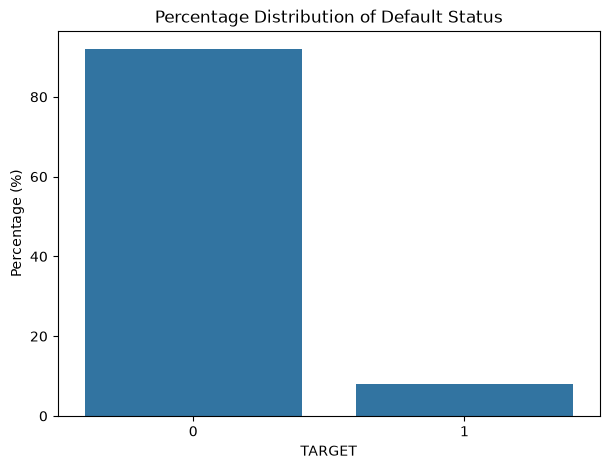

In [39]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=target_percentage.index,
    y=target_percentage.values
)

plt.title('Percentage Distribution of Default Status')
plt.xlabel('TARGET')
plt.ylabel('Percentage (%)')

plt.show()

### Interpretation

The target variable shows a significant class imbalance, with default cases representing a much smaller proportion of the dataset compared to non-default cases. In this dataset, approximately 92% of customers belong to the non-default class, while only about 8% belong to the default class.

This imbalance is expected in credit risk problems because the majority of borrowers successfully repay their loans, while only a smaller percentage experience default. However, this creates a modelling challenge because machine learning algorithms may become biased towards the majority class and fail to correctly identify customers who are at higher risk of default.

To address this challenge, imbalance handling techniques will be considered during the modelling stage rather than during exploratory data analysis. The effectiveness of different approaches will be evaluated based on their impact on model performance.


## Linear Separability Analysis

Linear separability analysis evaluates whether customers who default and those who do not default can be distinguished using a linear decision boundary based on the available features.

If the classes are linearly separable, simpler models such as Logistic Regression may perform well because they can distinguish between the two classes using weighted combinations of features.

However, if the classes overlap significantly, more complex non-linear models such as Random Forest, XGBoost, and LightGBM may be more suitable because they can capture complex relationships and interactions between variables.

This analysis helps guide the selection of appropriate modelling techniques.

The scatter plots show substantial overlap between defaulters and non-defaulters across most numerical features. This indicates that the data is not linearly separable, as no single feature can clearly distinguish the two classes using a straight decision boundary. The presence of skewed distributions, outliers, and overlapping observations suggests that loan default is influenced by complex interactions among multiple variables rather than a simple linear relationship. Therefore, machine learning models capable of capturing non-linear patterns, such as Random Forest, XGBoost, LightGBM, or CatBoost, are likely to perform better than models that rely solely on linear decision boundaries.

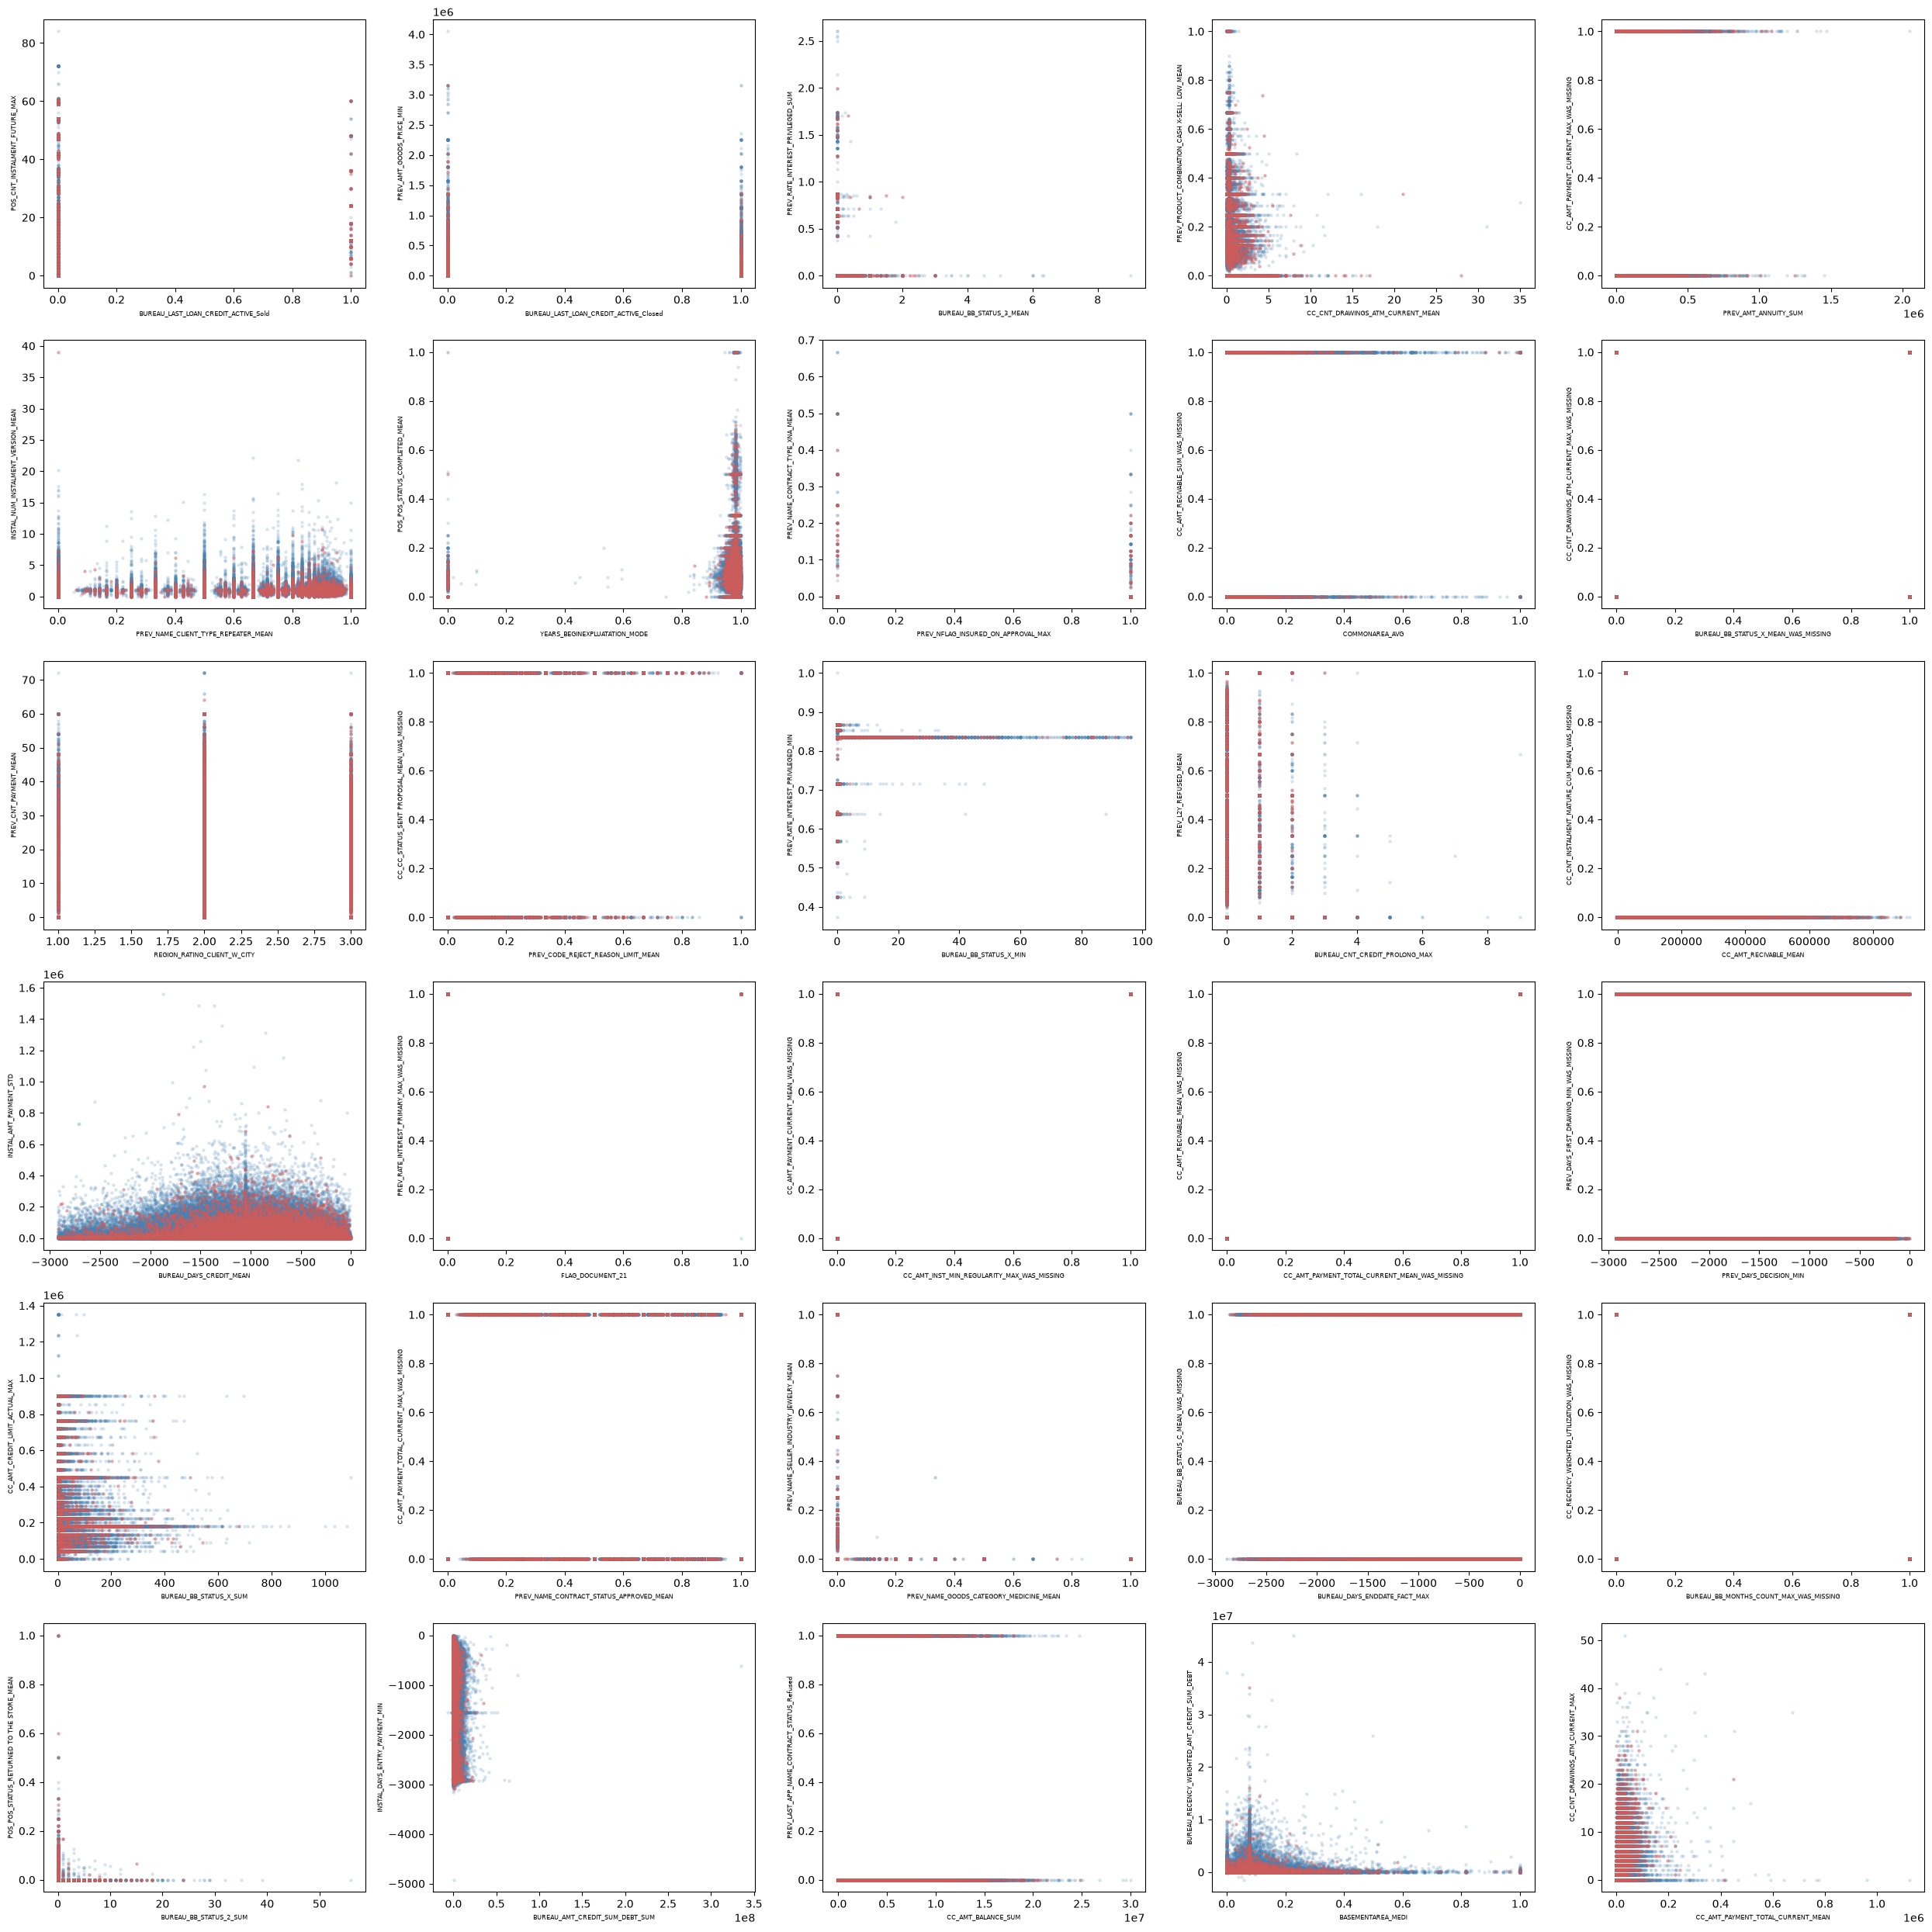

In [40]:
num_df = train_clean.select_dtypes(include=['number'])

feature_only_cols = [
    c for c in num_df.columns
    if c not in ['TARGET', 'SK_ID_CURR']
]

comb = list(itertools.combinations(range(len(feature_only_cols)), 2))
rand = random.sample(comb, k=30)

fig = plt.figure(figsize=(25, 25))
for i, (a, b) in enumerate(rand):
    ax = fig.add_subplot(6, 5, i + 1)
    col_a, col_b = feature_only_cols[a], feature_only_cols[b]

    majority = num_df[num_df['TARGET'] == 0]
    minority = num_df[num_df['TARGET'] == 1]
    ax.scatter(majority[col_a], majority[col_b], c='steelblue', alpha=0.15, s=5)
    ax.scatter(minority[col_a], minority[col_b], c='indianred', alpha=0.4, s=5)
    ax.set_xlabel(col_a, fontsize=6)
    ax.set_ylabel(col_b, fontsize=6)

plt.tight_layout()
plt.show()


In [41]:
# Final validation before saving the cleaned datasets

assert train_clean.isna().sum().sum() == 0
assert test_clean.isna().sum().sum() == 0

assert (train_clean["DAYS_EMPLOYED"] == 365243).sum() == 0
assert (test_clean["DAYS_EMPLOYED"] == 365243).sum() == 0

assert np.isinf(train_clean.select_dtypes(include=np.number)).sum().sum() == 0
assert np.isinf(test_clean.select_dtypes(include=np.number)).sum().sum() == 0

print(" All data quality checks passed. The datasets are ready for feature engineering.")

 All data quality checks passed. The datasets are ready for feature engineering.


Before saving the cleaned datasets, I carried out a final data quality check to make sure the data was ready for feature engineering and machine learning. I confirmed that there were no missing values remaining, verified that the placeholder value (365243) in the DAYS_EMPLOYED feature had been completely removed, and checked that there were no infinite values that could have been introduced during data processing. These validation checks ensured that the datasets were clean, consistent, and suitable for the next stage of the project.

## Saving the data set afre EDA and basic cleaning

In [42]:
# Create output folder if it doesn't exist
OUTPUT_DIR = Path("./output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save cleaned datasets
train_clean.to_parquet(
    OUTPUT_DIR / "train_clean_eda.parquet",
    index=False
)

test_clean.to_parquet(
    OUTPUT_DIR / "test_clean_eda.parquet",
    index=False
)

print(f" Clean EDA datasets successfully saved to: {OUTPUT_DIR.resolve()}")

 Clean EDA datasets successfully saved to: C:\Users\User\Desktop\final project\output


In [43]:
print(list(OUTPUT_DIR.glob("*.parquet")))

[WindowsPath('output/agg_bureau.parquet'), WindowsPath('output/agg_bureau_balance.parquet'), WindowsPath('output/agg_credit_card.parquet'), WindowsPath('output/agg_installments.parquet'), WindowsPath('output/agg_pos_cash.parquet'), WindowsPath('output/agg_previous_app.parquet'), WindowsPath('output/test_clean_eda.parquet'), WindowsPath('output/test_final.parquet'), WindowsPath('output/train_clean_eda.parquet'), WindowsPath('output/train_final.parquet')]
